# **Object Detection with DETR**

In [ ]:
import os
import json
import torch
from torch import nn, optim
import torchvision.transforms as tt
from torchvision.models import resnet50
import requests
from PIL import Image, ImageDraw, ImageFont
import numpy as np
from torchsummary import summary
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import CocoDetection 
import matplotlib.pyplot as plt 

#Switch off the grad since this notebook uses pretrained weights
torch.set_grad_enabled(True);

In [2]:
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]
print(f"The length of classes in COCO dataset is {len(CLASSES)}")

# colors for plotting objects
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

The length of classes in COCO dataset is 91


In [3]:
annotations_file = '/kaggle/input/coco2017/annotations/instances_train2017.json'
train_images_dir = '/kaggle/input/coco2017/train2017'

In [4]:
# Define the target size
target_size = (640, 640)
def collate_fn(batch):
    images, targets = zip(*batch)
    
    # Resize all images to the target size
    resized_images = [transforms.Resize(target_size)(image) for image in images]
    
    # Convert images to tensors
    images_tensor = torch.stack([transforms.ToTensor()(img) for img in resized_images])
    
    # Ensure targets are in the correct format
    formatted_targets = []
    for target in targets:
        # Extract bounding boxes and class labels
        boxes = [t['bbox'] for t in target]  # Adjust based on your target structure
        labels = [t['category_id'] for t in target]  # Adjust based on your target structure
        formatted_targets.append({
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64)
        })
    
    return images_tensor, formatted_targets

# Load the COCO dataset
coco_train_dataset = CocoDetection(root=train_images_dir, annFile=annotations_file)
train_loader = DataLoader(coco_train_dataset, batch_size=2, shuffle=True, num_workers=4, collate_fn=collate_fn)

loading annotations into memory...
Done (t=16.55s)
creating index...
index created!


torch.Size([2, 3, 640, 640])


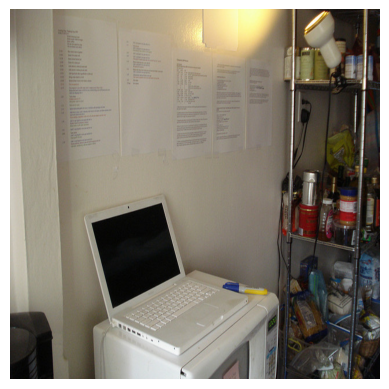

{'boxes': tensor([[570.2400, 230.8500,  30.8200,  49.8400],
        [548.6600, 214.7400,  20.7100,  36.0600],
        [615.4900, 238.7300,  14.8800,  42.4000],
        [584.9900, 202.6900,  34.0700,  81.4100],
        [532.1300, 244.9000,  28.6300,  56.3800],
        [616.0300, 212.0300,  11.1000,  27.1100],
        [126.7100, 236.3500, 288.8600, 213.6900],
        [143.4400, 365.2000, 320.3600, 114.8000],
        [598.9600,  59.4000,  30.2400,  33.3100]]), 'labels': tensor([44, 44, 44, 44, 44, 44, 73, 78, 44])}


In [5]:
for images, targets in train_loader:
    # Display the first image in the batch
    print(images.shape)
    plt.imshow(images[0].permute(1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
    plt.axis('off')
    plt.show()
    
    # Print the targets (annotations) for the first image
    print(targets[0])  # Each target is a list of annotations for the corresponding image
    break

## **Custom DETR model**

In [6]:
# Define the custom DETR implementation
class DETR(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, num_heads=8, n_encoder_layers=6, n_decoder_layers=6):
        super().__init__()

        # Backbone: ResNet-50
        self.backbone = resnet50()
        del self.backbone.fc  # Remove fully connected layer

        self.conv = nn.Conv2d(in_channels=2048, out_channels=hidden_dim, kernel_size=1)

        # Transformer
        self.transformer = nn.Transformer(
            d_model=hidden_dim, nhead=num_heads,
            num_encoder_layers=n_encoder_layers, num_decoder_layers=n_decoder_layers
        )

        # Classification and bounding box prediction heads
        self.linear_class = nn.Linear(hidden_dim, num_classes + 1)
        self.linear_bbox = nn.Linear(hidden_dim, 4)

        # Object queries and positional embeddings
        self.query_pos = nn.Parameter(torch.rand(100, hidden_dim))
        self.row_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))  # Row positional embeddings
        self.col_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))  # Column positional embeddings

    def forward(self, inputs):
        # Forward pass through ResNet-50 backbone
        x = self.backbone.conv1(inputs)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
    
        x = self.conv(x)  # Reduce channels to hidden_dim
    
        # Positional embeddings
        H, W = x.shape[-2:]
        pos = torch.cat([
            self.col_embed[:W].unsqueeze(0).repeat(H, 1, 1),  # Column embeddings
            self.row_embed[:H].unsqueeze(1).repeat(1, W, 1),  # Row embeddings
        ], dim=-1).flatten(0, 1).unsqueeze(1)  # Flatten to (H * W, 1, hidden_dim)
    
        batch_size = x.shape[0]  # Extract batch size
        flattened_features = x.flatten(2).permute(2, 0, 1)  # Shape: (H * W, batch_size, hidden_dim)
    
        # Repeat object queries for each image in the batch
        query_pos = self.query_pos.unsqueeze(1).repeat(1, batch_size, 1)  # Shape: (num_queries, batch_size, hidden_dim)
    
        # Transformer
        t = self.transformer(pos + 0.1 * flattened_features, query_pos).transpose(0, 1)
    
        # Predictions
        return {
            'pred_logits': self.linear_class(t),  # Class logits
            'pred_boxes': self.linear_bbox(t).sigmoid()  # Bounding box coordinates
        }

In [7]:
from scipy.optimize import linear_sum_assignment

def hungarian_matching(outputs, targets):
    pred_logits = outputs['pred_logits']  # Shape: (batch_size, num_queries, num_classes + 1)
    pred_boxes = outputs['pred_boxes']    # Shape: (batch_size, num_queries, 4)

    # Convert logits to probabilities
    pred_probs = pred_logits.softmax(-1)  # Shape: (batch_size, num_queries, num_classes + 1)

    batch_size = pred_probs.shape[0]
    matched_indices = []

    for batch_idx in range(batch_size):
        # Target boxes and labels for this image
        tgt_boxes = targets[batch_idx]['boxes']
        tgt_labels = targets[batch_idx]['labels']

        # Handle cases where there are no ground truth boxes
        if tgt_boxes.numel() == 0:  # Check if tgt_boxes is empty
            matched_indices.append(([], []))  # No matches
            continue

        # Compute classification cost: -log(probability of the target class)
        cost_class = -pred_probs[batch_idx][:, tgt_labels].detach().cpu().numpy()

        # Compute bounding box cost (L1 distance)
        tgt_boxes = tgt_boxes.unsqueeze(0) if tgt_boxes.ndim == 1 else tgt_boxes  # Ensure 2D
        cost_boxes = torch.cdist(pred_boxes[batch_idx], tgt_boxes, p=1).detach().cpu().numpy()

        # Combine costs
        cost_matrix = cost_class + cost_boxes

        # Perform Hungarian matching
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        matched_indices.append((row_ind, col_ind))

    return matched_indices


In [8]:
def format_targets(targets):
    boxes = []
    labels = []
    
    for target in targets:
        # Extract bounding boxes and class labels
        boxes.append(torch.tensor(target['boxes'], dtype=torch.float32))
        labels.append(torch.tensor(target['labels'], dtype=torch.int64))
    
    # Concatenate all boxes and labels
    boxes = torch.cat(boxes, dim=0) if boxes else torch.empty((0, 4))  # Ensure boxes is a tensor
    labels = torch.cat(labels, dim=0) if labels else torch.empty((0,))  # Ensure labels is a tensor
    
    return boxes, labels

In [9]:
from torch.nn import functional as F

def detr_loss(outputs, targets, matched_indices):
    pred_logits = outputs['pred_logits']  # Shape: (batch_size, num_queries, num_classes + 1)
    pred_boxes = outputs['pred_boxes']    # Shape: (batch_size, num_queries, 4)

    batch_size = len(targets)
    class_loss = 0.0
    bbox_loss = 0.0

    for batch_idx, (pred_idx, tgt_idx) in enumerate(matched_indices):
        # Matched predictions and targets
        matched_logits = pred_logits[batch_idx][pred_idx]
        matched_boxes = pred_boxes[batch_idx][pred_idx]

        tgt_labels = targets[batch_idx]['labels'][tgt_idx]
        tgt_boxes = targets[batch_idx]['boxes'][tgt_idx]

        # Classification loss
        class_loss += F.cross_entropy(matched_logits, tgt_labels)

        # Bounding box regression loss (only if there are ground truth boxes)
        if tgt_boxes.size(0) > 0:  # Ensure there are ground truth boxes
            bbox_loss += F.l1_loss(matched_boxes, tgt_boxes)

    # Average losses over the batch
    class_loss = class_loss / batch_size if batch_size > 0 else torch.tensor(0.0, device=pred_logits.device)
    bbox_loss = bbox_loss / batch_size if batch_size > 0 else torch.tensor(0.0, device=pred_boxes.device)

    return class_loss + bbox_loss


## **Train DETR model**

In [ ]:
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DETR(num_classes=len(CLASSES), n_encoder_layers=4, n_decoder_layers=4).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 10

for epoch in range(num_epochs):
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    
    # Use tqdm for progress bar
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch + 1}/{num_epochs}")
    
    for images, targets in progress_bar:
        # Move images and targets to the correct device
        images = images.to(device)
        formatted_targets = []
        for target in targets:
            formatted_targets.append({
                'boxes': target['boxes'].to(device),
                'labels': target['labels'].to(device)
            })

        # Forward pass
        outputs = model(images)
        
        # Hungarian matching and loss calculation (as implemented earlier)
        matched_indices = hungarian_matching(outputs, formatted_targets)
        loss = detr_loss(outputs, formatted_targets, matched_indices)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Update progress bar and epoch loss
        epoch_loss += loss.item()
        progress_bar.set_postfix({"Batch Loss": loss.item()})
    
    # Print epoch loss
    epoch_loss /= len(train_loader)
    print(f"Epoch [{epoch + 1}/{num_epochs}] - Average Loss: {epoch_loss:.4f}")


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/10]


Training Epoch 1/10:   4%|▍         | 2311/59144 [07:58<3:16:19,  4.82it/s, Batch Loss=201] 